In [ ]:
# import liberarys
# örnek veris seti 
# word2vec
# fasttext
# görselleştirme pca

In [6]:
! pip install gensim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess


In [3]:
sentences=[
    "köpekler çok tatlı bir hayvandır",
    "kediler çok sevimli bir hayvandır",
    "köpekler ve kediler evcil hayvanlardır",
    "köpekler sadık hayvanlardır",
    "kediler bağırsak hastalığına yatkındır",
    "hayvanlar insanlara arkadaşlık eder"
]

In [5]:
tokenizer_sentences=[simple_preprocess(sentence) for sentence in sentences]
print(tokenizer_sentences)

[['köpekler', 'çok', 'tatlı', 'bir', 'hayvandır'], ['kediler', 'çok', 'sevimli', 'bir', 'hayvandır'], ['köpekler', 've', 'kediler', 'evcil', 'hayvanlardır'], ['köpekler', 'sadık', 'hayvanlardır'], ['kediler', 'bağırsak', 'hastalığına', 'yatkındır'], ['hayvanlar', 'insanlara', 'arkadaşlık', 'eder']]


In [7]:
Word2Vec_model=Word2Vec(tokenizer_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=0)
FastText_model=FastText(tokenizer_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=0)

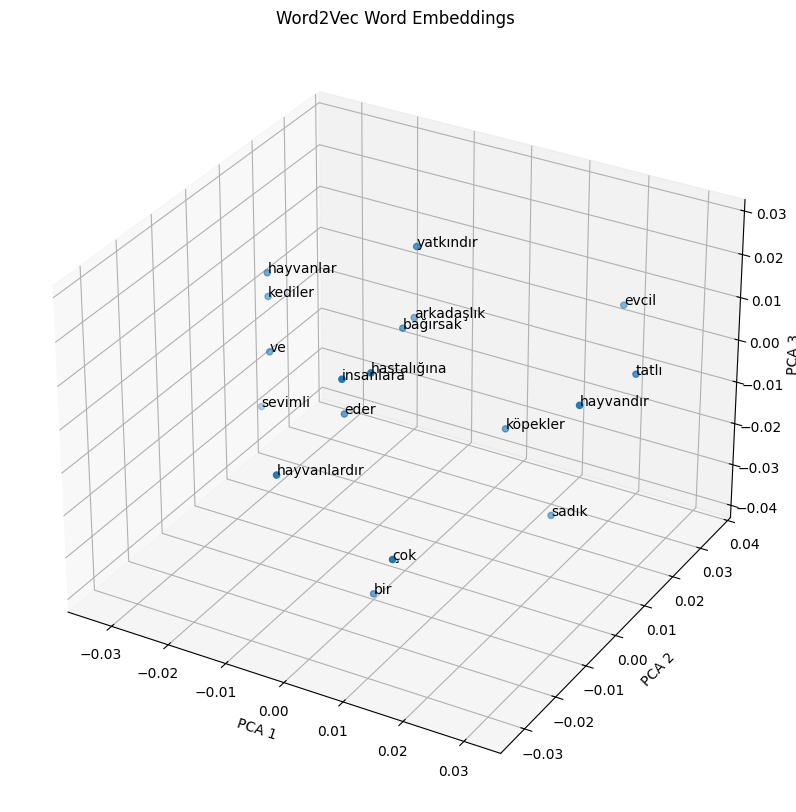

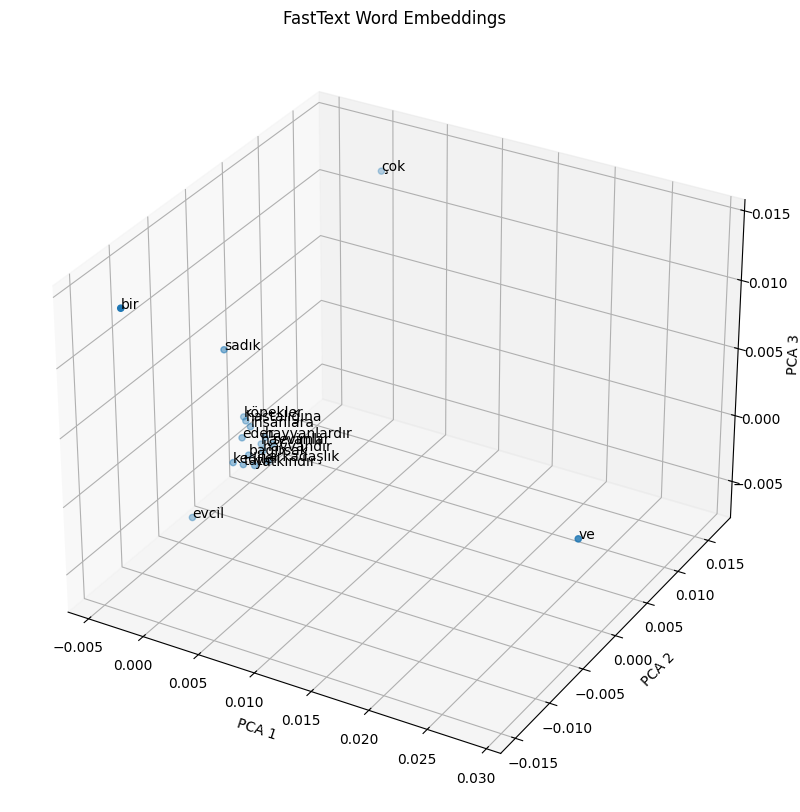

In [13]:
def plot_word_embedding(model,title):
    word_vectors=model.wv
    words=list(word_vectors.index_to_key)[:100]
    vectors=[word_vectors[word] for word in words]

    pca=PCA(n_components=3)
    vectors_2d=pca.fit_transform(vectors)

    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111,projection='3d')

    ax.scatter(vectors_2d[:,0],vectors_2d[:,1],vectors_2d[:,2])

    for i,word in enumerate(words):
        ax.text(vectors_2d[i,0],vectors_2d[i,1],vectors_2d[i,2],word)

    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')
    plt.show()

plot_word_embedding(Word2Vec_model,"Word2Vec Word Embeddings")
plot_word_embedding(FastText_model,"FastText Word Embeddings")